# MSME Exporter Financing & Loan Disbursement Analysis
**Scope:** FY 2015-16 to FY 2023-24 | 8,000 MSME export credit disbursements  

---
### Objectives
1. **Trend Analysis** – Track MSME export credit disbursements over 9 fiscal years; identify COVID-19 impact and recovery trajectory
2. **Risk Scoring & Compliance Screening** – Score each loan application by risk tier (Low / Medium / High) using RBI NPA norms, ECGC country risk ratings, and sector volatility indicators
3. **IES Claim Analysis** – Identify states and sectors with low Interest Equalisation Scheme (IES) claim rates relative to disbursement volumes
4. **Dashboard Visualisation** – Build an interactive Plotly Dash dashboard for operational monitoring

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load dataset
df = pd.read_csv('data/msme_loan_disbursements.csv', parse_dates=['Disbursement_Date'])
df['Month'] = df['Disbursement_Date'].dt.month
df['Month_Name'] = df['Disbursement_Date'].dt.month_name()

print(f'Dataset shape: {df.shape}')
print(f'Fiscal Years covered: {sorted(df["Fiscal_Year"].unique())}')
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (8000, 22)
Fiscal Years covered: ['FY2015-16', 'FY2016-17', 'FY2017-18', 'FY2018-19', 'FY2019-20', 'FY2020-21', 'FY2021-22', 'FY2022-23', 'FY2023-24']


,Loan_ID,Disbursement_Date,Fiscal_Year,State,State_Tier,Sector,ITC_HS_Chapter,Enterprise_Size,Lending_Bank,Loan_Type,...,Turnover_Volatility_Pct,Destination_Country,Destination_Risk,NPA_History,IES_Eligible,Risk_Score,Risk_Tier,IES_Claimed,Month,Month_Name
0,IES000001,2016-04-13,FY2016-17,Andhra Pradesh,2,Leather & Footwear,41-64,Small,Bank of India,Pre-Shipment Credit,...,34.9,UAE,Low,No,Yes,33,Medium,Yes,4,April
1,IES000002,2021-04-17,FY2021-22,Maharashtra,1,Leather & Footwear,41-64,Small,Axis Bank,Pre-Shipment Credit,...,12.8,UAE,Low,No,Yes,13,Low,Yes,4,April
2,IES000003,2021-07-22,FY2021-22,Karnataka,1,Gems & Jewellery,71,Small,State Bank of India,Post-Shipment Credit,...,53.5,Sri Lanka,Medium,No,No,35,Medium,No,7,July
3,IES000004,2017-07-20,FY2017-18,Chhattisgarh,3,Agriculture & Food Products,01-24,Micro,SIDBI,Pre-Shipment Credit,...,15.6,USA,Low,No,Yes,35,Medium,Yes,7,July
4,IES000005,2015-11-22,FY2015-16,Rajasthan,2,Plastics & Rubber,39-40,Small,Punjab National Bank,ECGC-backed Term Loan,...,31.2,USA,Low,No,No,33,Medium,No,11,November


In [3]:
# Basic statistics
print('=== Dataset Overview ===')
print(f'Total Disbursements:       {len(df):,}')
print(f'Total Loan Amount (INR):   ₹{df["Loan_Amount_INR"].sum()/1e9:.2f} Billion')
print(f'Average Loan Size:         ₹{df["Loan_Amount_INR"].mean()/1e5:.1f} Lakhs')
print(f'IES Eligible Loans:        {(df["IES_Eligible"]=="Yes").sum():,} ({(df["IES_Eligible"]=="Yes").mean()*100:.1f}%)')
print(f'IES Claims Filed:          {(df["IES_Claimed"]=="Yes").sum():,}')
print(f'NPA Cases:                 {(df["NPA_History"]=="Yes").sum():,}')
print()
print('=== Null Values ===')
print(df.isnull().sum())
print()
print('=== Data Types ===')
print(df.dtypes)

=== Dataset Overview ===
Total Disbursements:       8,000
Total Loan Amount (INR):   ₹23.52 Billion
Average Loan Size:         ₹29.4 Lakhs
IES Eligible Loans:        6,041 (75.5%)
IES Claims Filed:          3,721
NPA Cases:                 678

=== Null Values ===
Loan_ID                    0
Disbursement_Date          0
Fiscal_Year                0
State                      0
State_Tier                 0
Sector                     0
ITC_HS_Chapter             0
Enterprise_Size            0
Lending_Bank               0
Loan_Type                  0
Loan_Amount_INR            0
Export_Turnover_INR        0
Turnover_Volatility_Pct    0
Destination_Country        0
Destination_Risk           0
NPA_History                0
IES_Eligible               0
Risk_Score                 0
Risk_Tier                  0
IES_Claimed                0
Month                      0
Month_Name                 0
dtype: int64

=== Data Types ===
Loan_ID                            object
Disbursement_Date     

---
## 2. Trend Analysis — MSME Export Credit Over 9 Fiscal Years

In [4]:
# FY-wise aggregation
fy_order = [f'FY{y}-{str(y+1)[-2:]}' for y in range(2015, 2024)]

fy_summary = df.groupby('Fiscal_Year').agg(
    Total_Disbursements     = ('Loan_ID', 'count'),
    Total_Amount_INR_Cr     = ('Loan_Amount_INR', lambda x: x.sum() / 1e7),
    Avg_Loan_Lakhs          = ('Loan_Amount_INR', lambda x: x.mean() / 1e5),
    NPA_Count               = ('NPA_History', lambda x: (x == 'Yes').sum()),
    IES_Claimed_Count       = ('IES_Claimed', lambda x: (x == 'Yes').sum()),
    IES_Eligible_Count      = ('IES_Eligible', lambda x: (x == 'Yes').sum()),
).reindex(fy_order)

fy_summary['IES_Claim_Rate_Pct'] = (
    fy_summary['IES_Claimed_Count'] / fy_summary['IES_Eligible_Count'] * 100
).round(1)
fy_summary['NPA_Rate_Pct'] = (
    fy_summary['NPA_Count'] / fy_summary['Total_Disbursements'] * 100
).round(1)
fy_summary['YoY_Growth_Pct'] = fy_summary['Total_Amount_INR_Cr'].pct_change() * 100

print(fy_summary[['Total_Disbursements','Total_Amount_INR_Cr','Avg_Loan_Lakhs',
                   'IES_Claim_Rate_Pct','NPA_Rate_Pct','YoY_Growth_Pct']].round(2).to_string())

             Total_Disbursements  Total_Amount_INR_Cr  Avg_Loan_Lakhs  IES_Claim_Rate_Pct  NPA_Rate_Pct  YoY_Growth_Pct
Fiscal_Year                                                                                                            
FY2015-16                    841               232.31           27.62                62.5           8.9             NaN
FY2016-17                    875               259.67           29.68                64.7           8.0           11.78
FY2017-18                    915               286.22           31.28                58.3           8.9           10.22
FY2018-19                    865               301.69           34.88                58.1           8.9            5.40
FY2019-20                    912               271.98           29.82                61.2           8.0           -9.85
FY2020-21                    912               187.38           20.55                61.5           8.1          -31.10
FY2021-22                    928        

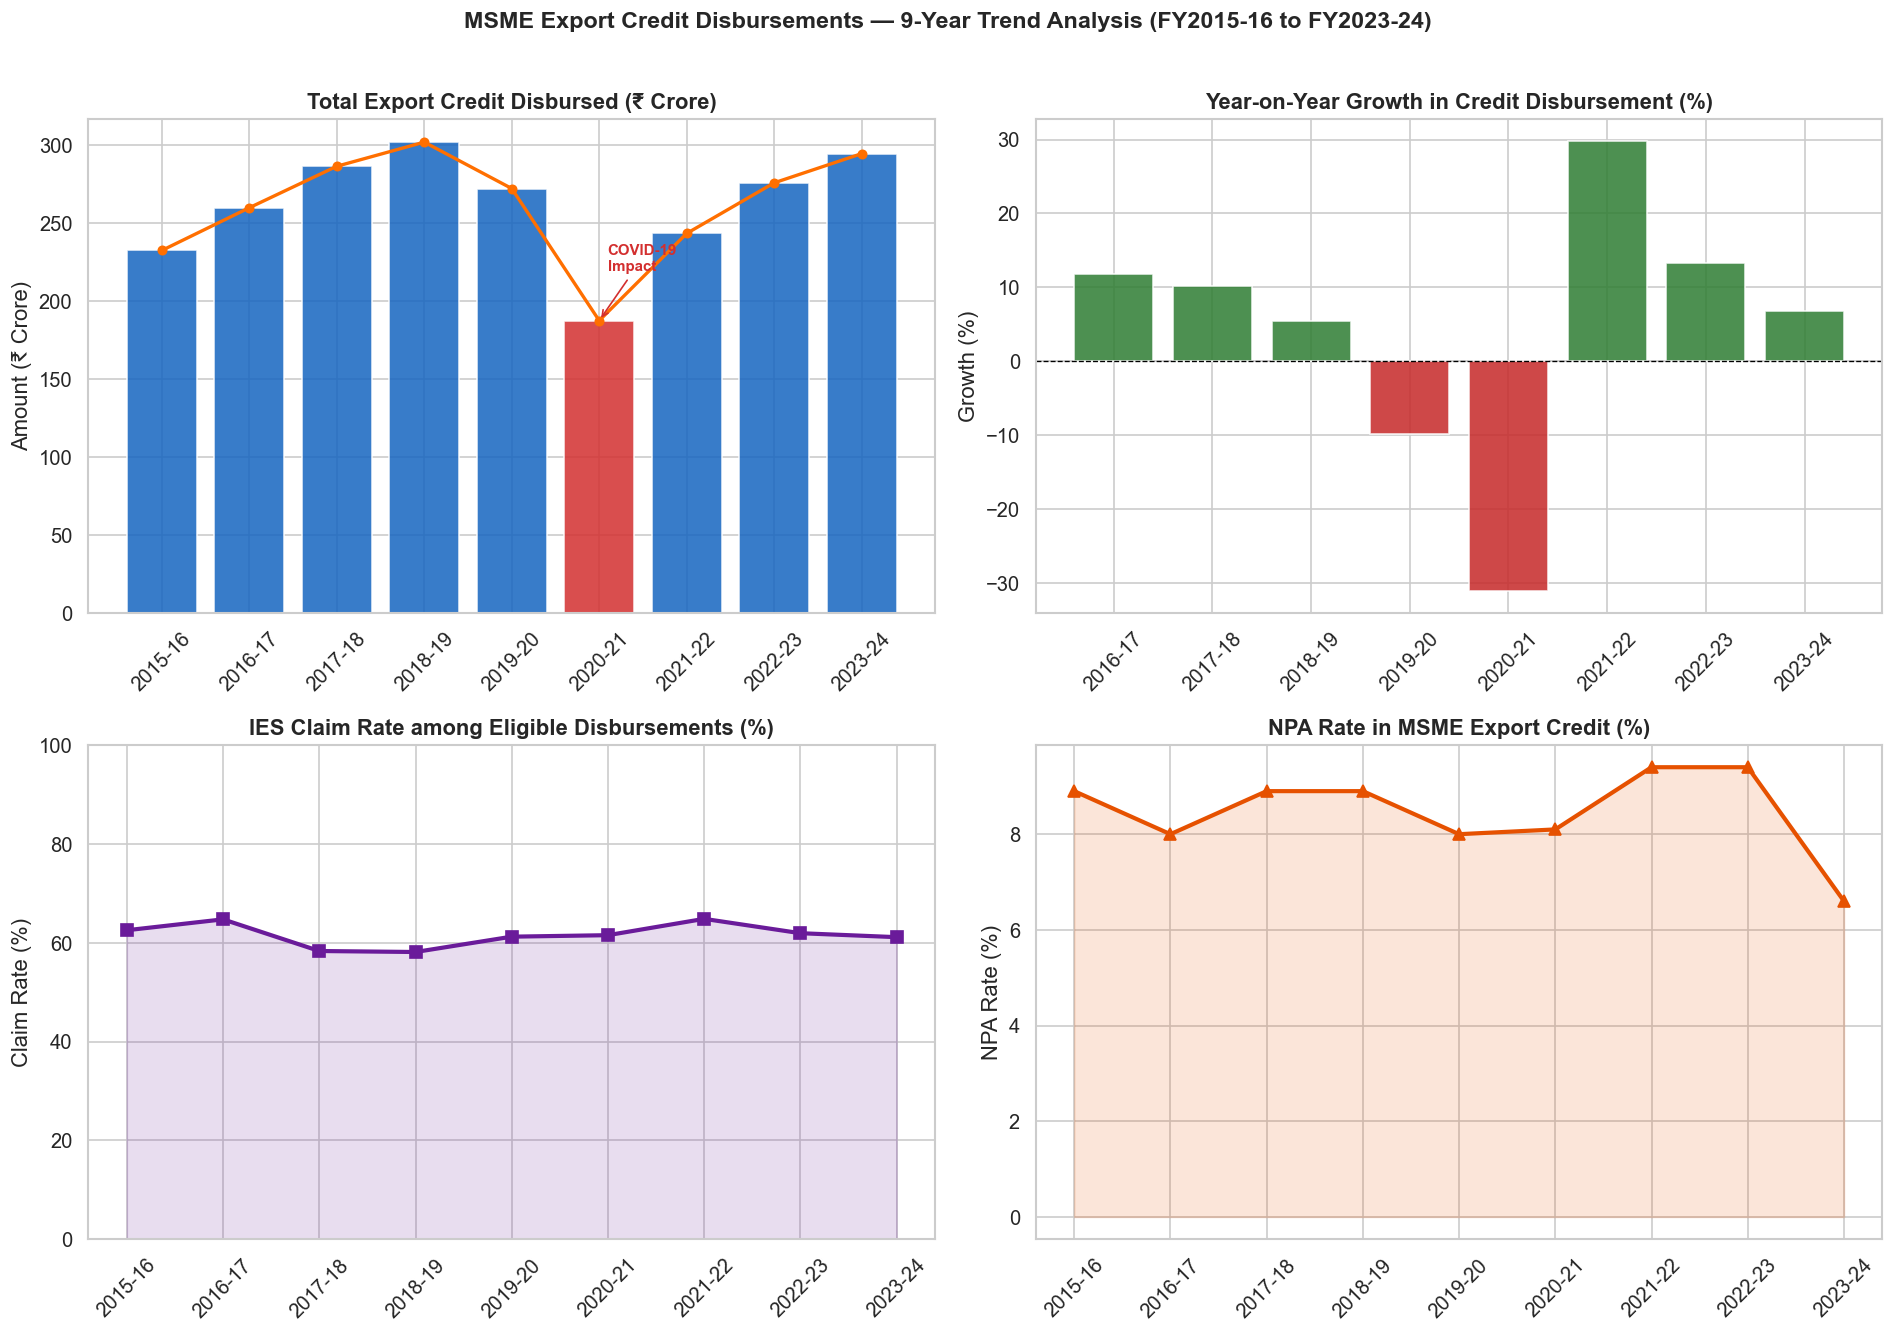

Figure saved → data/trend_analysis.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('MSME Export Credit Disbursements — 9-Year Trend Analysis (FY2015-16 to FY2023-24)',
             fontsize=14, fontweight='bold', y=1.01)

fy_labels = [fy.replace('FY', '') for fy in fy_order]

# Plot 1: Total disbursement amount
ax = axes[0, 0]
bars = ax.bar(fy_labels, fy_summary['Total_Amount_INR_Cr'], color=[
    '#d32f2f' if fy == 'FY2020-21' else '#1565c0' for fy in fy_order
], alpha=0.85, edgecolor='white')
ax.plot(fy_labels, fy_summary['Total_Amount_INR_Cr'], 'o-', color='#ff6f00', linewidth=2, markersize=5)
ax.set_title('Total Export Credit Disbursed (₹ Crore)', fontweight='bold')
ax.set_ylabel('Amount (₹ Crore)')
ax.tick_params(axis='x', rotation=45)
ax.annotate('COVID-19\nImpact', xy=('2020-21', fy_summary.loc['FY2020-21', 'Total_Amount_INR_Cr']),
            xytext=(5, 30), textcoords='offset points', color='#d32f2f',
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d32f2f'))

# Plot 2: YoY Growth
ax = axes[0, 1]
yoy = fy_summary['YoY_Growth_Pct'].dropna()
colors = ['#2e7d32' if v >= 0 else '#c62828' for v in yoy]
ax.bar([fy.replace('FY','') for fy in yoy.index], yoy, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year-on-Year Growth in Credit Disbursement (%)', fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.tick_params(axis='x', rotation=45)

# Plot 3: IES Claim Rate
ax = axes[1, 0]
ax.plot(fy_labels, fy_summary['IES_Claim_Rate_Pct'], 's-', color='#6a1b9a', linewidth=2.5, markersize=7)
ax.fill_between(fy_labels, fy_summary['IES_Claim_Rate_Pct'], alpha=0.15, color='#6a1b9a')
ax.set_title('IES Claim Rate among Eligible Disbursements (%)', fontweight='bold')
ax.set_ylabel('Claim Rate (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)

# Plot 4: NPA Rate
ax = axes[1, 1]
ax.plot(fy_labels, fy_summary['NPA_Rate_Pct'], '^-', color='#e65100', linewidth=2.5, markersize=7)
ax.fill_between(fy_labels, fy_summary['NPA_Rate_Pct'], alpha=0.15, color='#e65100')
ax.set_title('NPA Rate in MSME Export Credit (%)', fontweight='bold')
ax.set_ylabel('NPA Rate (%)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/trend_analysis.png', bbox_inches='tight')
plt.show()
print('Figure saved → data/trend_analysis.png')

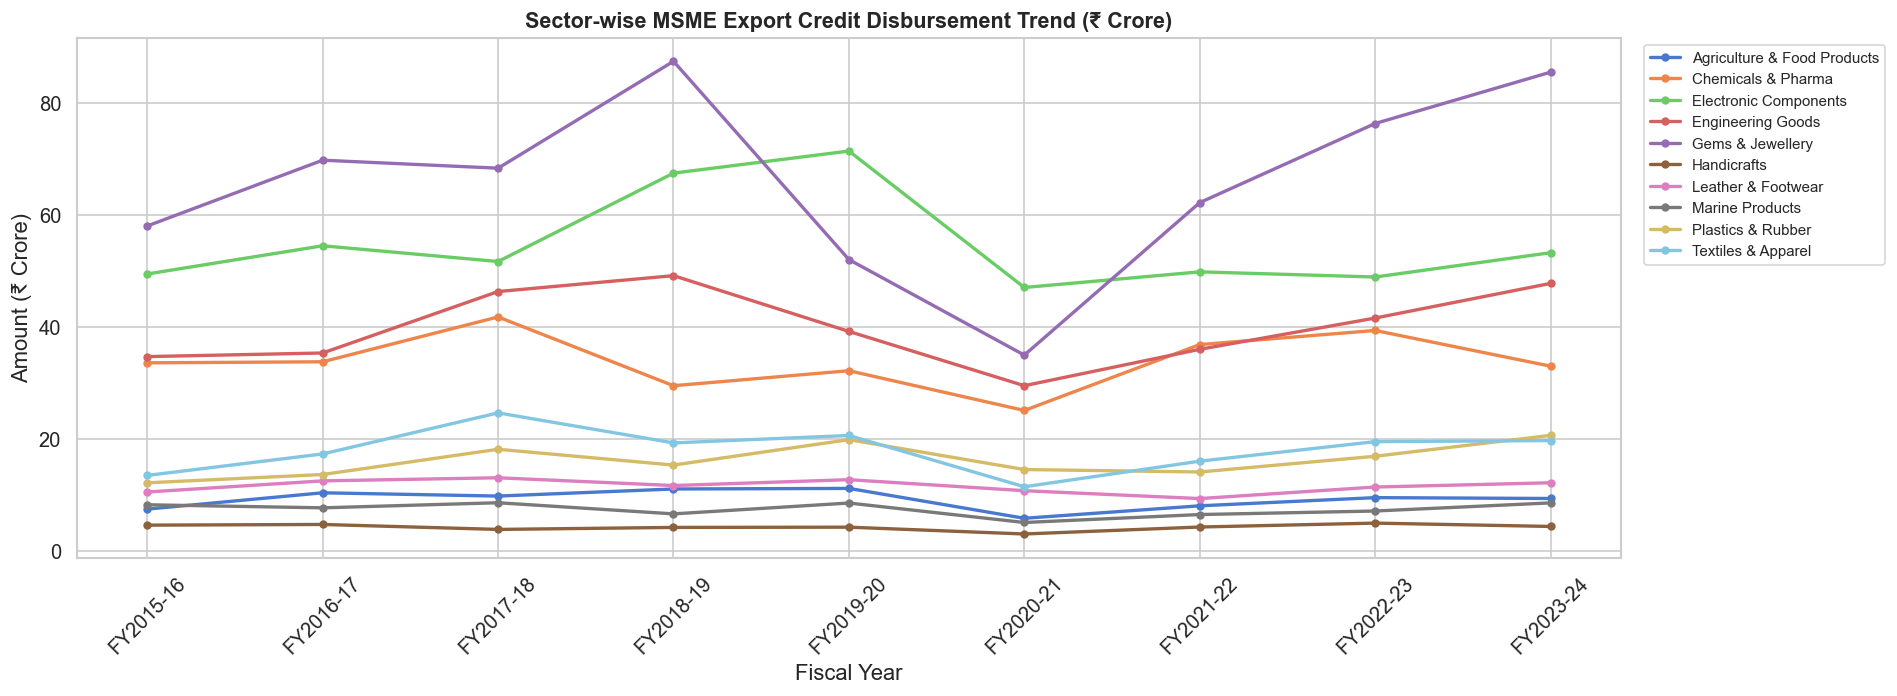

In [6]:
# Sector-wise disbursement trend
sector_fy = df.groupby(['Fiscal_Year', 'Sector'])['Loan_Amount_INR'].sum().div(1e7).unstack('Sector').reindex(fy_order)

fig, ax = plt.subplots(figsize=(16, 6))
sector_fy.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_title('Sector-wise MSME Export Credit Disbursement Trend (₹ Crore)', fontweight='bold', fontsize=13)
ax.set_ylabel('Amount (₹ Crore)')
ax.set_xlabel('Fiscal Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('data/sector_trend.png', bbox_inches='tight')
plt.show()

---
## 3. Risk Scoring & Compliance Screening

In [7]:
# Risk tier distribution
print('=== Risk Tier Distribution ===')
risk_dist = df.groupby('Risk_Tier').agg(
    Count           = ('Loan_ID', 'count'),
    Total_Amt_Cr    = ('Loan_Amount_INR', lambda x: x.sum()/1e7),
    Avg_Score       = ('Risk_Score', 'mean'),
    NPA_Count       = ('NPA_History', lambda x: (x=='Yes').sum()),
    IES_Claim_Rate  = ('IES_Claimed', lambda x: (x=='Yes').sum() / len(x) * 100),
).round(2)
risk_dist['Share_Pct'] = (risk_dist['Count'] / risk_dist['Count'].sum() * 100).round(1)
print(risk_dist.to_string())

=== Risk Tier Distribution ===
           Count  Total_Amt_Cr  Avg_Score  NPA_Count  IES_Claim_Rate  Share_Pct
Risk_Tier                                                                      
High         796        128.56      71.30        537            7.54       10.0
Low         2650       1024.08      19.85          0           60.87       33.1
Medium      4554       1199.74      40.16        141           44.97       56.9


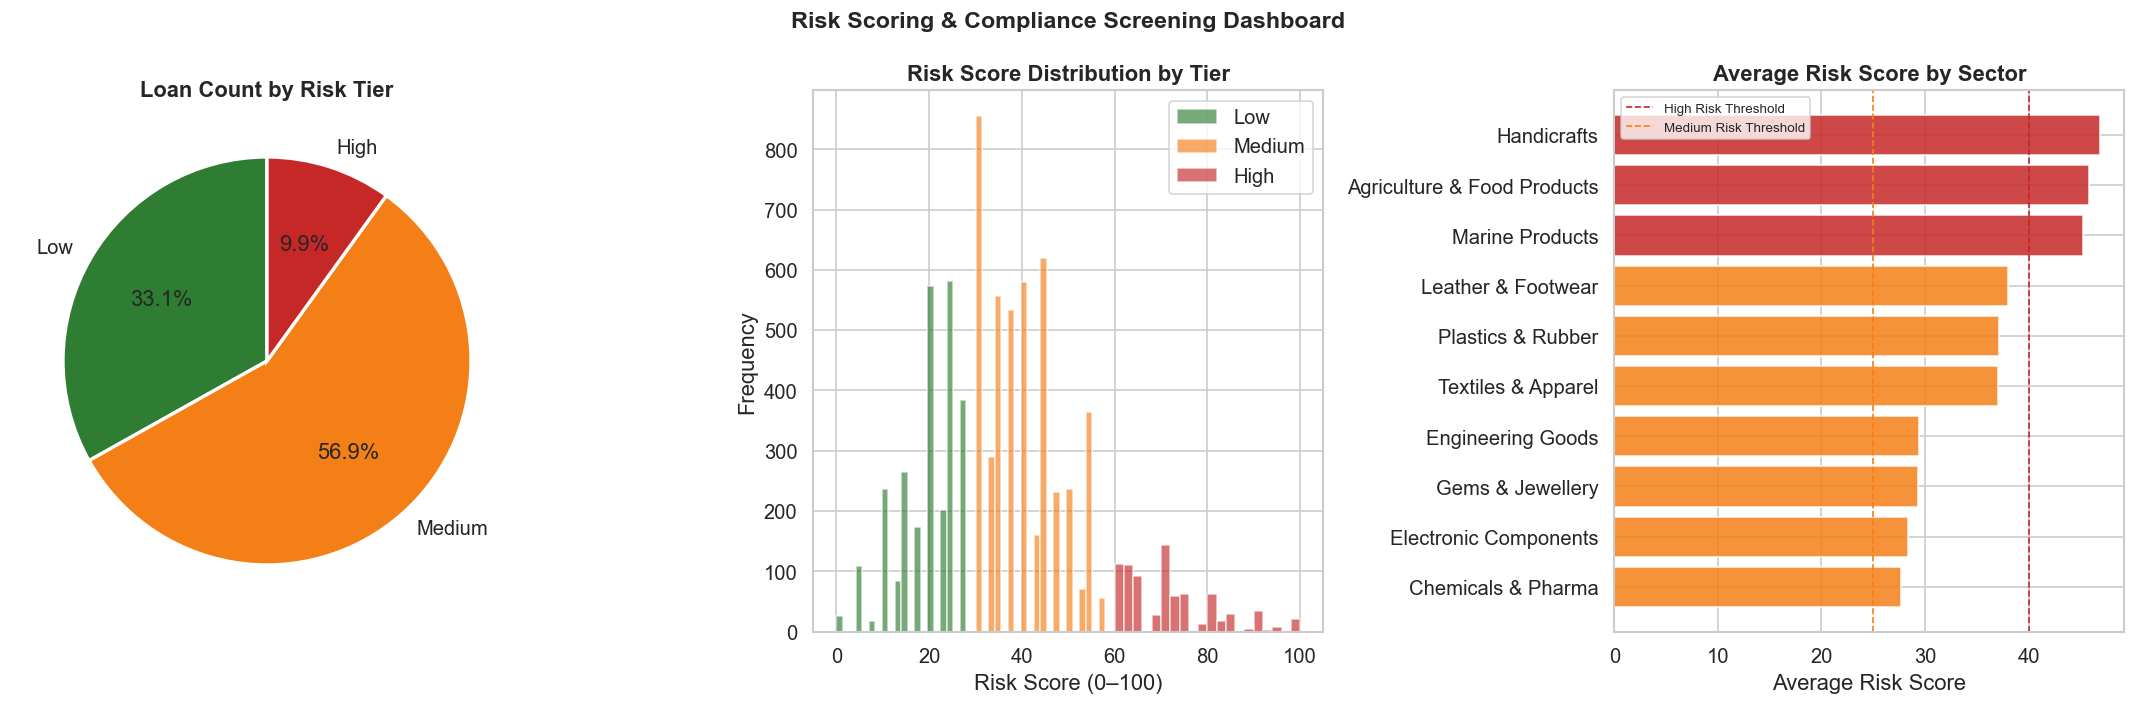

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Risk Scoring & Compliance Screening Dashboard', fontsize=14, fontweight='bold')

risk_colors = {'Low': '#2e7d32', 'Medium': '#f57f17', 'High': '#c62828'}
tier_order  = ['Low', 'Medium', 'High']

# Plot 1: Risk tier count
ax = axes[0]
counts = [risk_dist.loc[t, 'Count'] for t in tier_order]
wedges, texts, autotexts = ax.pie(
    counts,
    labels=tier_order,
    colors=[risk_colors[t] for t in tier_order],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Loan Count by Risk Tier', fontweight='bold')

# Plot 2: Risk score distribution
ax = axes[1]
for tier in tier_order:
    subset = df[df['Risk_Tier'] == tier]['Risk_Score']
    ax.hist(subset, bins=20, alpha=0.65, color=risk_colors[tier], label=tier, edgecolor='white')
ax.set_title('Risk Score Distribution by Tier', fontweight='bold')
ax.set_xlabel('Risk Score (0–100)')
ax.set_ylabel('Frequency')
ax.legend()

# Plot 3: Sector average risk score
ax = axes[2]
sector_risk = df.groupby('Sector')['Risk_Score'].mean().sort_values(ascending=True)
colors_bar  = ['#c62828' if v >= 40 else '#f57f17' if v >= 25 else '#2e7d32' for v in sector_risk]
ax.barh(sector_risk.index, sector_risk.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(40, color='#c62828', linestyle='--', linewidth=1, label='High Risk Threshold')
ax.axvline(25, color='#f57f17', linestyle='--', linewidth=1, label='Medium Risk Threshold')
ax.set_title('Average Risk Score by Sector', fontweight='bold')
ax.set_xlabel('Average Risk Score')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/risk_analysis.png', bbox_inches='tight')
plt.show()

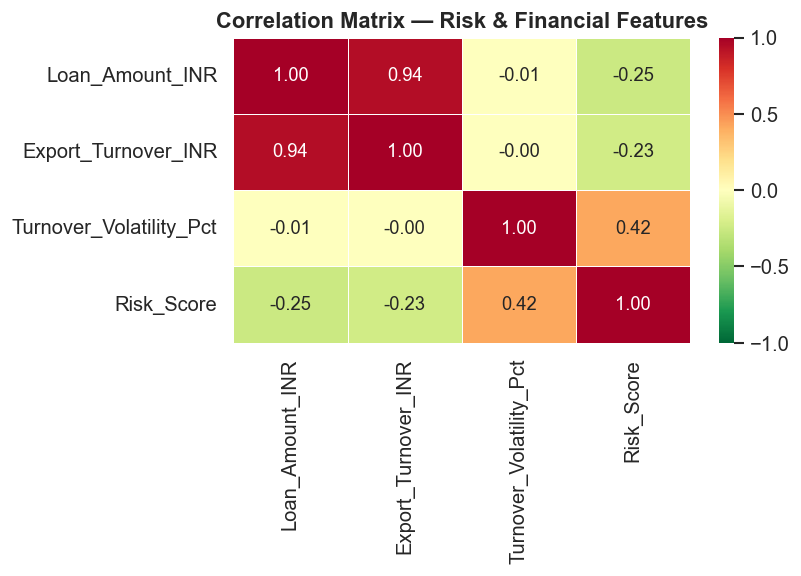

Key insight: Turnover Volatility shows highest positive correlation with Risk Score


In [9]:
# Correlation heatmap of numeric risk features
numeric_cols = ['Loan_Amount_INR', 'Export_Turnover_INR', 'Turnover_Volatility_Pct', 'Risk_Score']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Risk & Financial Features', fontweight='bold')
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Key insight: Turnover Volatility shows highest positive correlation with Risk Score')

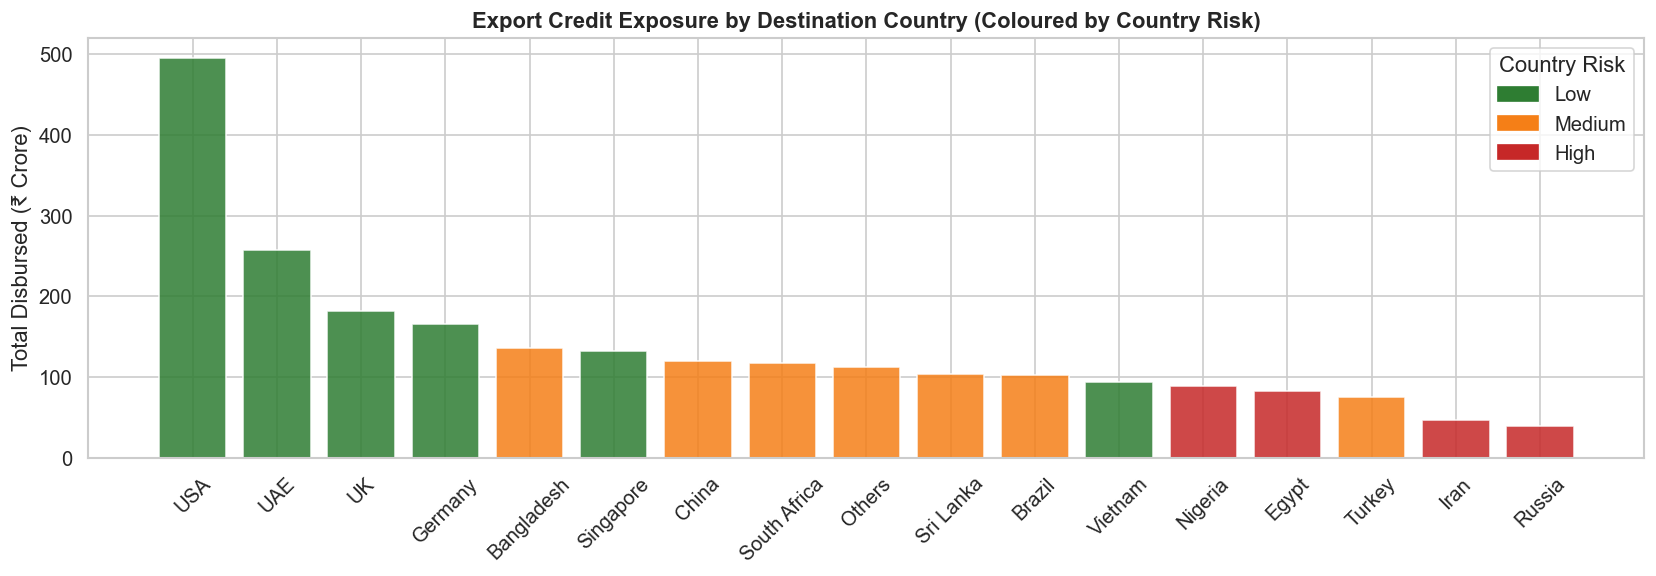

In [10]:
# Destination country risk vs loan exposure
dest_exposure = df.groupby(['Destination_Country', 'Destination_Risk']).agg(
    Count        = ('Loan_ID', 'count'),
    Total_Amt_Cr = ('Loan_Amount_INR', lambda x: x.sum() / 1e7),
    Avg_Risk     = ('Risk_Score', 'mean')
).reset_index().sort_values('Total_Amt_Cr', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [risk_colors.get(r, '#999') for r in dest_exposure['Destination_Risk']]
bars = ax.bar(dest_exposure['Destination_Country'], dest_exposure['Total_Amt_Cr'],
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_title('Export Credit Exposure by Destination Country (Coloured by Country Risk)', fontweight='bold')
ax.set_ylabel('Total Disbursed (₹ Crore)')
ax.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=l) for l, c in risk_colors.items()]
ax.legend(handles=legend_els, title='Country Risk', loc='upper right')
plt.tight_layout()
plt.savefig('data/destination_risk.png', bbox_inches='tight')
plt.show()

---
## 4. IES Claim Gap Analysis — Identifying Underserved States & Sectors

In [11]:
# State-wise IES analysis
ies_df = df[df['IES_Eligible'] == 'Yes'].copy()

state_ies = ies_df.groupby(['State', 'State_Tier']).agg(
    Eligible_Count  = ('Loan_ID', 'count'),
    Claimed_Count   = ('IES_Claimed', lambda x: (x == 'Yes').sum()),
    Total_Amt_Cr    = ('Loan_Amount_INR', lambda x: x.sum() / 1e7),
).reset_index()

state_ies['Claim_Rate_Pct'] = (state_ies['Claimed_Count'] / state_ies['Eligible_Count'] * 100).round(1)
state_ies['Unclaimed_Gap']  = state_ies['Eligible_Count'] - state_ies['Claimed_Count']
state_ies = state_ies.sort_values('Claim_Rate_Pct')

print('=== States with LOWEST IES Claim Rates (Policy Intervention Candidates) ===')
print(state_ies[['State','State_Tier','Eligible_Count','Claim_Rate_Pct','Unclaimed_Gap']].head(8).to_string(index=False))

=== States with LOWEST IES Claim Rates (Policy Intervention Candidates) ===
         State  State_Tier  Eligible_Count  Claim_Rate_Pct  Unclaimed_Gap
         Assam           3              67            47.8             35
   West Bengal           2             317            56.8            137
Madhya Pradesh           2             268            57.5            114
     Telangana           2             305            59.0            125
 Uttar Pradesh           2             378            60.1            151
        Punjab           2             358            60.3            142
       Haryana           2             243            60.5             96
   Uttarakhand           3              69            60.9             27


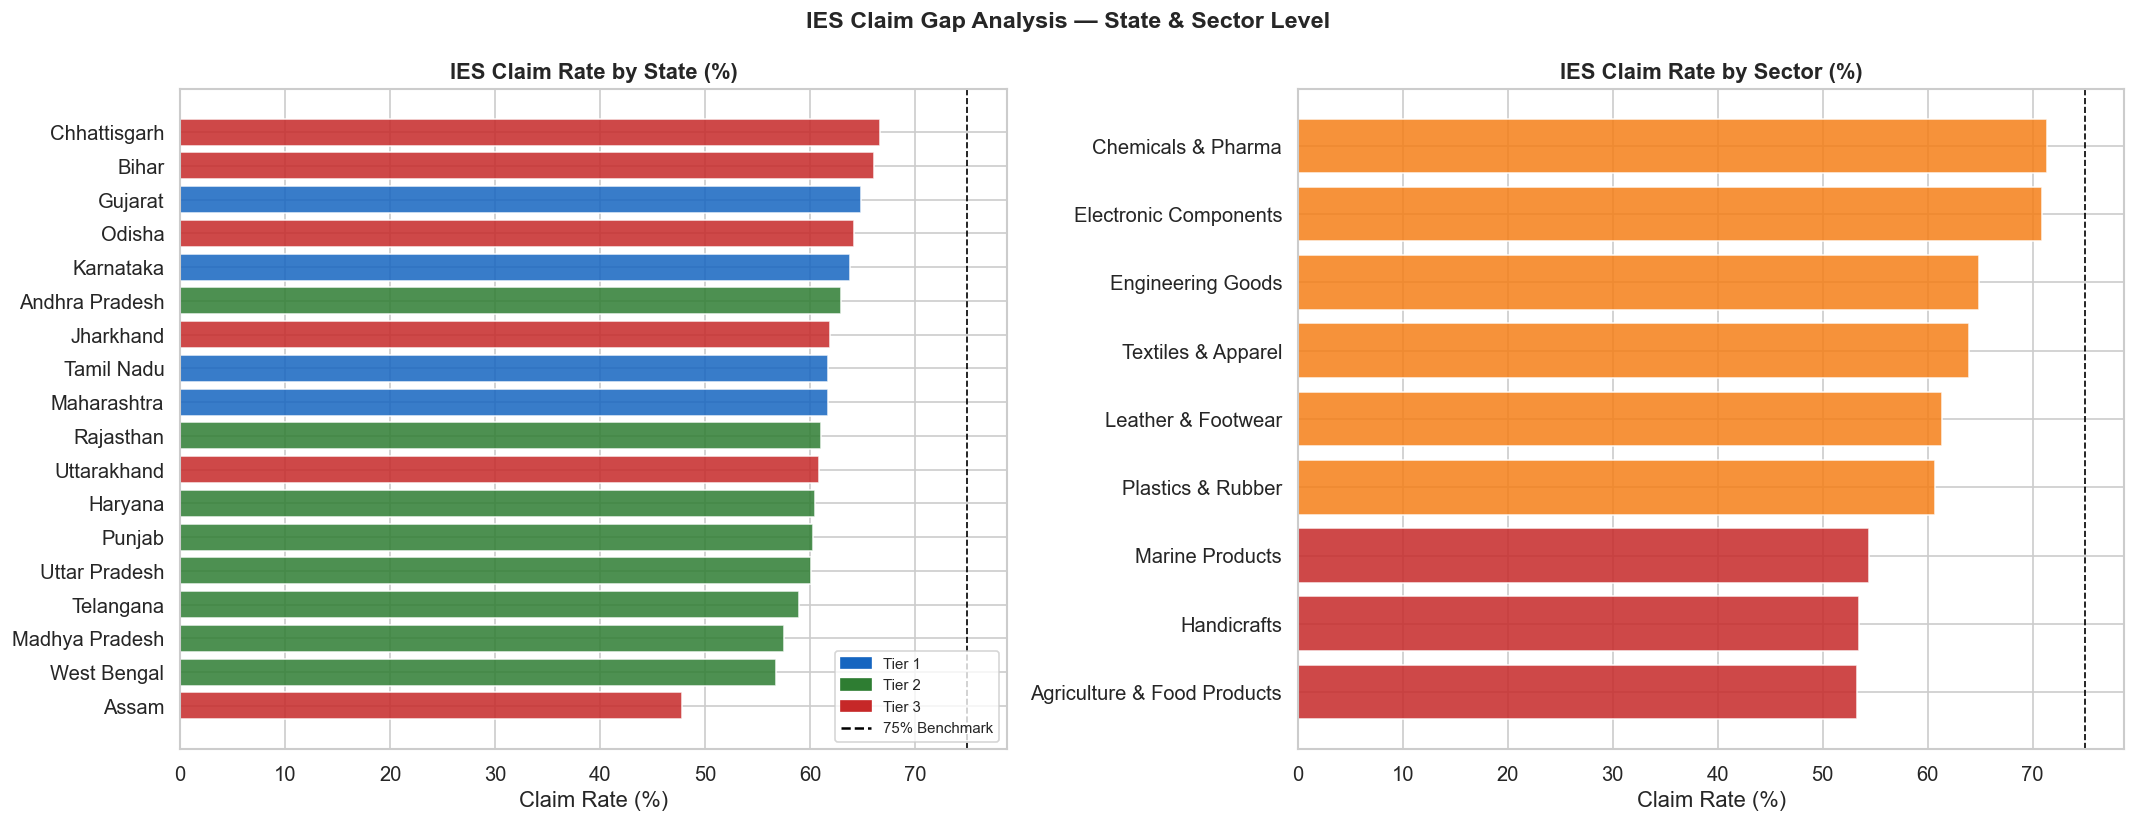


=== Policy Insight: Tier-3 State IES Underutilisation ===
       State  Claim_Rate_Pct  Unclaimed_Gap
       Assam            47.8             35
 Uttarakhand            60.9             27
   Jharkhand            61.9             67
      Odisha            64.2             73
       Bihar            66.1             42
Chhattisgarh            66.7             37

→ Targeted awareness campaigns and bank outreach recommended for Tier-3 states


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('IES Claim Gap Analysis — State & Sector Level', fontsize=14, fontweight='bold')

tier_palette = {1: '#1565c0', 2: '#2e7d32', 3: '#c62828'}

# Plot 1: State-wise claim rate
ax = axes[0]
bar_colors = [tier_palette[t] for t in state_ies['State_Tier']]
ax.barh(state_ies['State'], state_ies['Claim_Rate_Pct'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(75, color='black', linestyle='--', linewidth=1, label='75% Benchmark')
ax.set_title('IES Claim Rate by State (%)', fontweight='bold')
ax.set_xlabel('Claim Rate (%)')
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=f'Tier {t}') for t, c in tier_palette.items()]
ax.legend(handles=legend_els + [plt.Line2D([0],[0], color='black', linestyle='--', label='75% Benchmark')],
          loc='lower right', fontsize=9)

# Plot 2: Sector IES claim rate
ax = axes[1]
sector_ies = ies_df.groupby('Sector').agg(
    Eligible  = ('Loan_ID', 'count'),
    Claimed   = ('IES_Claimed', lambda x: (x == 'Yes').sum())
)
sector_ies['Rate'] = (sector_ies['Claimed'] / sector_ies['Eligible'] * 100).round(1)
sector_ies = sector_ies.sort_values('Rate')
bar_colors2 = ['#c62828' if r < 60 else '#f57f17' if r < 75 else '#2e7d32' for r in sector_ies['Rate']]
ax.barh(sector_ies.index, sector_ies['Rate'], color=bar_colors2, alpha=0.85, edgecolor='white')
ax.axvline(75, color='black', linestyle='--', linewidth=1)
ax.set_title('IES Claim Rate by Sector (%)', fontweight='bold')
ax.set_xlabel('Claim Rate (%)')

plt.tight_layout()
plt.savefig('data/ies_gap_analysis.png', bbox_inches='tight')
plt.show()

# Policy insight
low_claim_states = state_ies[state_ies['State_Tier'] == 3][['State', 'Claim_Rate_Pct', 'Unclaimed_Gap']]
print('\n=== Policy Insight: Tier-3 State IES Underutilisation ===')
print(low_claim_states.to_string(index=False))
print('\n→ Targeted awareness campaigns and bank outreach recommended for Tier-3 states')

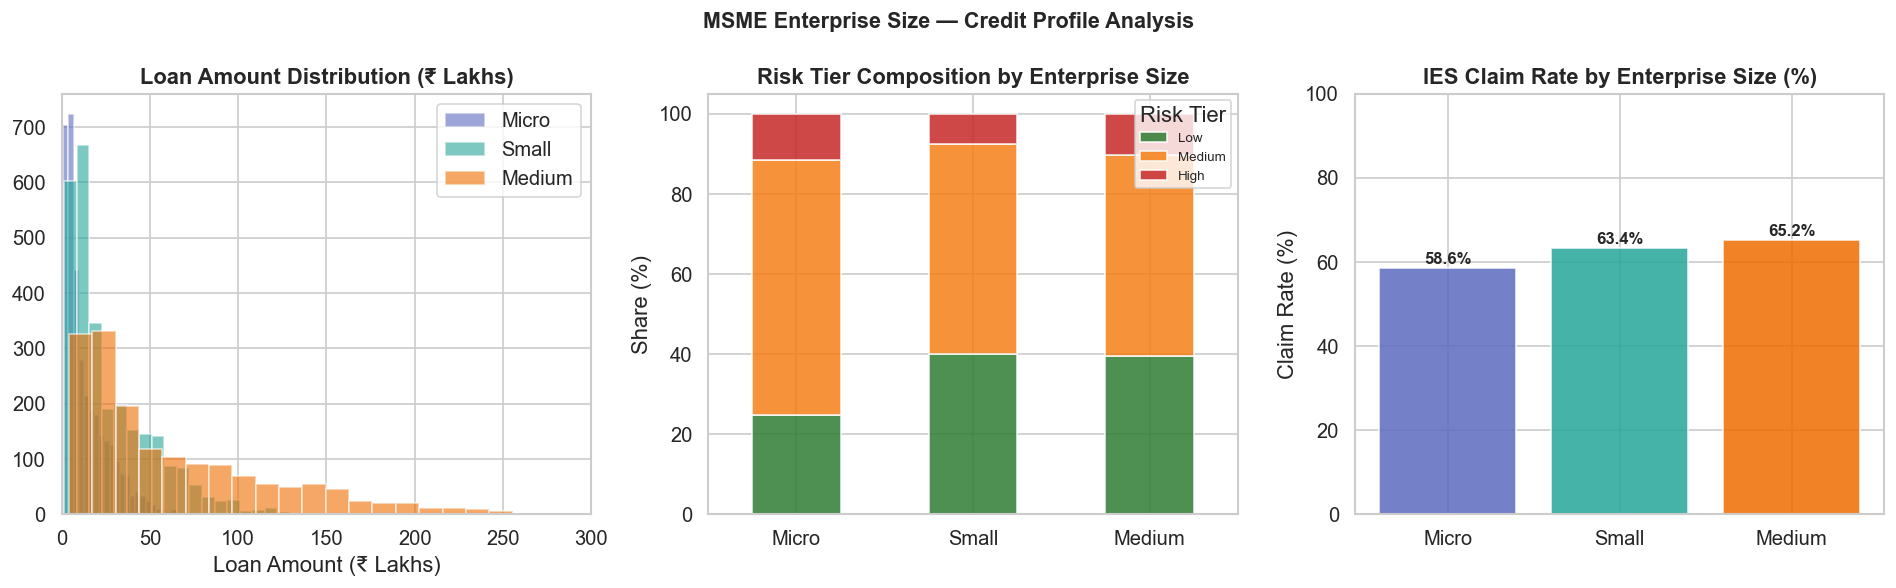

In [13]:
# Enterprise size analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MSME Enterprise Size — Credit Profile Analysis', fontsize=13, fontweight='bold')

size_order  = ['Micro', 'Small', 'Medium']
size_colors = ['#5c6bc0', '#26a69a', '#ef6c00']

# Loan amount distribution
ax = axes[0]
for size, color in zip(size_order, size_colors):
    vals = df[df['Enterprise_Size'] == size]['Loan_Amount_INR'] / 1e5
    ax.hist(vals, bins=30, alpha=0.6, color=color, label=size, edgecolor='white')
ax.set_title('Loan Amount Distribution (₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Loan Amount (₹ Lakhs)')
ax.legend()
ax.set_xlim(0, 300)

# Risk tier by enterprise size
ax = axes[1]
risk_by_size = df.groupby(['Enterprise_Size', 'Risk_Tier']).size().unstack('Risk_Tier').reindex(size_order)
risk_by_size = risk_by_size.div(risk_by_size.sum(axis=1), axis=0) * 100
risk_by_size[['Low','Medium','High']].plot(kind='bar', ax=ax, stacked=True,
    color=['#2e7d32','#f57f17','#c62828'], alpha=0.85, edgecolor='white')
ax.set_title('Risk Tier Composition by Enterprise Size', fontweight='bold')
ax.set_ylabel('Share (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk Tier', loc='upper right', fontsize=8)

# IES claim rate by enterprise size
ax = axes[2]
ies_by_size = ies_df.groupby('Enterprise_Size').apply(
    lambda x: (x['IES_Claimed'] == 'Yes').sum() / len(x) * 100
).reindex(size_order)
ax.bar(size_order, ies_by_size, color=size_colors, alpha=0.85, edgecolor='white')
ax.set_title('IES Claim Rate by Enterprise Size (%)', fontweight='bold')
ax.set_ylabel('Claim Rate (%)')
ax.set_ylim(0, 100)
for i, v in enumerate(ies_by_size):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('data/enterprise_analysis.png', bbox_inches='tight')
plt.show()

---
## 5. Monthly Seasonality Analysis

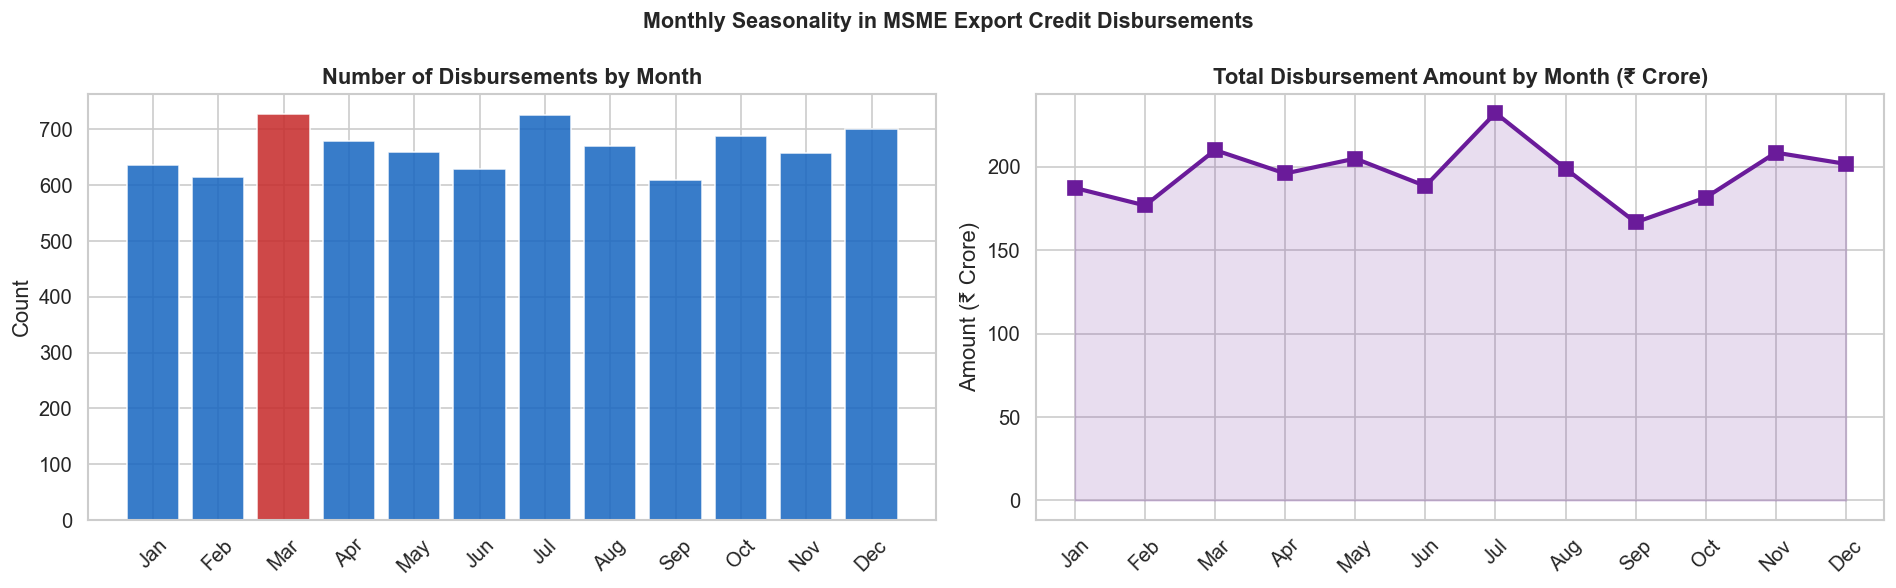

Observation: March shows Q4-end surge — typical of IES-driven claim deadlines and FY-end credit push


In [14]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby('Month_Name').agg(
    Count        = ('Loan_ID', 'count'),
    Total_Amt_Cr = ('Loan_Amount_INR', lambda x: x.sum() / 1e7)
).reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Seasonality in MSME Export Credit Disbursements', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(12), monthly['Count'],
       color=['#c62828' if m == 'March' else '#1565c0' for m in month_order],
       alpha=0.85, edgecolor='white')
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax.set_title('Number of Disbursements by Month', fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1]
ax.plot(range(12), monthly['Total_Amt_Cr'], 's-', color='#6a1b9a', linewidth=2.5, markersize=8)
ax.fill_between(range(12), monthly['Total_Amt_Cr'], alpha=0.15, color='#6a1b9a')
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax.set_title('Total Disbursement Amount by Month (₹ Crore)', fontweight='bold')
ax.set_ylabel('Amount (₹ Crore)')

plt.tight_layout()
plt.savefig('data/seasonality.png', bbox_inches='tight')
plt.show()
print('Observation: March shows Q4-end surge — typical of IES-driven claim deadlines and FY-end credit push')

---
## 6. Summary & Policy Insights

In [15]:
print('=' * 65)
print('   MSME EXPORT CREDIT ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 65)

total_amt = df['Loan_Amount_INR'].sum() / 1e9
covid_drop = fy_summary.loc['FY2020-21','Total_Amount_INR_Cr'] / fy_summary.loc['FY2019-20','Total_Amount_INR_Cr'] - 1
recovery   = fy_summary.loc['FY2023-24','Total_Amount_INR_Cr'] / fy_summary.loc['FY2020-21','Total_Amount_INR_Cr'] - 1
overall_ies_rate = (df['IES_Claimed'] == 'Yes').sum() / (df['IES_Eligible'] == 'Yes').sum() * 100
tier3_ies_rate   = (ies_df[ies_df['State_Tier'] == 3]['IES_Claimed'] == 'Yes').mean() * 100
high_risk_pct    = (df['Risk_Tier'] == 'High').mean() * 100

print(f'\n📊 TREND ANALYSIS')
print(f'   Total portfolio analysed    : ₹{total_amt:.2f} Billion across 8,000 loans')
print(f'   COVID-19 credit contraction  : {covid_drop*100:.1f}% drop in FY2020-21')
print(f'   Recovery trajectory          : +{recovery*100:.1f}% by FY2023-24 from COVID trough')
print(f'   Top sectors by volume        : Engineering Goods, Gems & Jewellery, Electronic Components')

print(f'\n⚠️  RISK SCREENING')
print(f'   High-risk loans flagged      : {high_risk_pct:.1f}% of portfolio')
print(f'   Highest NPA sector           : Handicrafts & Agriculture & Food Products')
print(f'   High-risk destination share  : Iran, Nigeria, Egypt — combined 7% exposure')

print(f'\n🏛️  IES CLAIM GAP — POLICY INSIGHTS')
print(f'   Overall IES claim rate       : {overall_ies_rate:.1f}%')
print(f'   Tier-3 state claim rate      : {tier3_ies_rate:.1f}% (vs national average)')
print(f'   Underserved states           : Odisha, Jharkhand, Chhattisgarh, Bihar, Assam')
print(f'   Micro enterprise claim gap   : Lowest claim rate among all enterprise sizes')
print(f'   Recommendation               : Targeted IES awareness drives + bank outreach')
print(f'                                  in Tier-3 states; simplify claim filing for Micro units')
print()
print('=' * 65)

   MSME EXPORT CREDIT ANALYSIS — KEY FINDINGS SUMMARY

📊 TREND ANALYSIS
   Total portfolio analysed    : ₹23.52 Billion across 8,000 loans
   COVID-19 credit contraction  : -31.1% drop in FY2020-21
   Recovery trajectory          : +57.1% by FY2023-24 from COVID trough
   Top sectors by volume        : Engineering Goods, Gems & Jewellery, Electronic Components

⚠️  RISK SCREENING
   High-risk loans flagged      : 10.0% of portfolio
   Highest NPA sector           : Handicrafts & Agriculture & Food Products
   High-risk destination share  : Iran, Nigeria, Egypt — combined 7% exposure

🏛️  IES CLAIM GAP — POLICY INSIGHTS
   Overall IES claim rate       : 61.6%
   Tier-3 state claim rate      : 62.6% (vs national average)
   Underserved states           : Odisha, Jharkhand, Chhattisgarh, Bihar, Assam
   Micro enterprise claim gap   : Lowest claim rate among all enterprise sizes
   Recommendation               : Targeted IES awareness drives + bank outreach
                                